<a href="https://colab.research.google.com/github/gavinmcaferty-eng/greentower-steel-model/blob/main/GreenTower_Model_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GreenTower Steel — Techno-Economic & Emissions Model
### ME798: Manufacturing for Energy Applications · Colab edition

Green hydrogen direct-reduced iron (H₂-DRI) + electric arc furnace (EAF), sited in the Kansas
wind corridor, making steel plate for wind-turbine towers.

**How to use:** Runtime → Run all. Then change values in the **Parameters** cell and re-run.
No installs needed — everything is numpy + matplotlib, both preloaded in Colab.

The three parameters that decide whether this concept works:
`grid_ci` (how clean the power really is), `h2_price`, and `elec_price`.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(42)
print("Ready.")

Ready.


## 1. Parameters — change anything here, then re-run

Every assumption lives in this one cell so nothing is hidden downstream.

In [31]:
# --- Process physics ---
H2_per_t      = 55.0    # kg H2 per ton steel (DRI stoichiometry)
elec_per_kgH2 = 52.0    # kWh per kg H2 (PEM electrolyzer)
eaf_kwh_per_t = 500.0   # kWh per ton (EAF melting)
co2_bfbof     = 2.30    # t CO2 / t steel, blast-furnace baseline (IRENA 2024)

# --- Plant / economics (paper pilot scale) ---
capacity_tpy   = 200e3  # t/yr
sale_price     = 1100.0 # $/t  (green premium price)
iron_ore_cost  = 120.0  # $/t steel
other_var_cost = 90.0   # $/t steel (fluxes, electrodes, consumables)
fixed_opex     = 30e6   # $/yr
capex          = 400e6  # $ pilot plant

# --- THE THREE DECISIVE KNOBS ---
grid_ci    = 0.03   # t CO2 / MWh   (0.03 = contracted clean wind; 0.37 = US avg grid)
h2_price   = 4.00   # $/kg hydrogen
elec_price = 45.0   # $/MWh electricity

# --- Comparison baselines ---
conv_var  = 450.0   # $/t conventional variable cost
conv_lcos = 550.0   # $/t conventional all-in cost
print("Parameters loaded.")

Parameters loaded.


## 2. Energy & emissions

Note the scope: this counts **electricity only** (electrolysis + EAF). Published figures near
14 GJ/t also include pelletizing and rolling — a boundary difference, not an error. State the
scope whenever you quote the number.

In [32]:
elec_h2_kwh  = H2_per_t * elec_per_kgH2
elec_tot_kwh = elec_h2_kwh + eaf_kwh_per_t
energy_green = elec_tot_kwh * 3.6 / 1000
co2_green    = elec_tot_kwh / 1000 * grid_ci
reduction    = 100 * (1 - co2_green / co2_bfbof)

print(f"Electricity for H2   : {elec_h2_kwh:,.0f} kWh/t  ({100*elec_h2_kwh/elec_tot_kwh:.0f}% of total)")
print(f"Total electricity    : {elec_tot_kwh:,.0f} kWh/t  ({energy_green:.1f} GJ/t, electricity only)")
print(f"Green route CO2      : {co2_green:.2f} t/t")
print(f"Reduction vs BF-BOF  : {reduction:.0f}%")

print("\nSensitivity to how clean the power actually is:")
for g, label in [(0.03,"contracted clean wind"), (0.10,"partially clean"), (0.37,"US average grid")]:
    c = elec_tot_kwh/1000*g
    print(f"  {g:.2f} t/MWh ({label:22s}) -> {c:.2f} t CO2/t  = {100*(1-c/co2_bfbof):3.0f}% reduction")

Electricity for H2   : 2,860 kWh/t  (85% of total)
Total electricity    : 3,360 kWh/t  (12.1 GJ/t, electricity only)
Green route CO2      : 0.10 t/t
Reduction vs BF-BOF  : 96%

Sensitivity to how clean the power actually is:
  0.03 t/MWh (contracted clean wind ) -> 0.10 t CO2/t  =  96% reduction
  0.10 t/MWh (partially clean       ) -> 0.34 t CO2/t  =  85% reduction
  0.37 t/MWh (US average grid       ) -> 1.24 t CO2/t  =  46% reduction


## 3. Cost per ton and pilot economics

Hydrogen is the dominant cost driver — watch how `h2_price` moves everything.

In [33]:
cost_h2   = H2_per_t * h2_price
cost_elec = elec_tot_kwh / 1000 * elec_price
var_cost  = cost_h2 + cost_elec + iron_ore_cost + other_var_cost

revenue = capacity_tpy * sale_price
ebitda  = revenue - capacity_tpy*var_cost - fixed_opex

print(f"Hydrogen      : ${cost_h2:6.0f}/t   ({100*cost_h2/var_cost:.0f}% of variable cost)")
print(f"Electricity   : ${cost_elec:6.0f}/t")
print(f"Ore + other   : ${iron_ore_cost+other_var_cost:6.0f}/t")
print(f"VARIABLE COST : ${var_cost:6.0f}/t")
print(f"\nRevenue       : ${revenue/1e6:,.0f}M/yr")
print(f"EBITDA        : ${ebitda/1e6:,.0f}M/yr  ({100*ebitda/revenue:.0f}% margin)")
print(f"Simple payback: {capex/ebitda:.1f} years")
print("\nNOTE: EBITDA excludes capital recovery. Section 5 is the honest full-cost view.")

Hydrogen      : $   220/t   (38% of variable cost)
Electricity   : $   151/t
Ore + other   : $   210/t
VARIABLE COST : $   581/t

Revenue       : $220M/yr
EBITDA        : $74M/yr  (34% margin)
Simple payback: 5.4 years

NOTE: EBITDA excludes capital recovery. Section 5 is the honest full-cost view.


## 4. Break-even surface — hydrogen price vs. carbon price

Green steel wins when its cost ≤ conventional cost + (carbon price × 2.3 t CO₂/t).
The black line is break-even; everything above/left of it is where green wins.

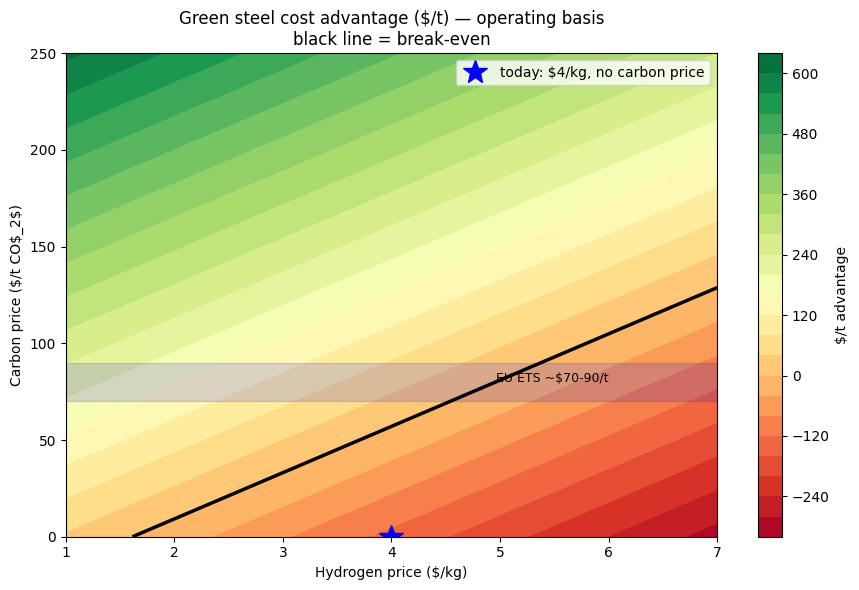

In [34]:
h2_range     = np.linspace(1, 7, 120)
carbon_range = np.linspace(0, 250, 120)
H2, C = np.meshgrid(h2_range, carbon_range)

green_cost = H2*H2_per_t + cost_elec + iron_ore_cost + other_var_cost
dirty_cost = conv_var + C*co2_bfbof
advantage  = dirty_cost - green_cost

fig, ax = plt.subplots(figsize=(9,6))
cf = ax.contourf(H2, C, advantage, 24, cmap='RdYlGn')
ax.contour(H2, C, advantage, [0], colors='k', linewidths=2.5)
ax.plot(h2_price, 0, 'b*', markersize=18, label='today: $4/kg, no carbon price')
ax.set_xlabel('Hydrogen price ($/kg)'); ax.set_ylabel('Carbon price ($/t CO$_2$)')
ax.set_title('Green steel cost advantage ($/t) — operating basis\nblack line = break-even')
ax.axhspan(70, 90, alpha=0.15, color='blue')
ax.text(6.0, 80, 'EU ETS ~$70-90/t', fontsize=9, ha='right')
ax.legend(loc='upper right'); plt.colorbar(cf, ax=ax, label='$/t advantage')
plt.tight_layout(); plt.show()

## 5. LCOS and the honest two-basis break-even

This is where the argument gets tested. **Operating basis** ignores capital; **full-LCOS basis**
amortizes it. The required carbon price differs enormously between them — present both.

In [35]:
r, n = 0.07, 15
crf = r*(1+r)**n / ((1+r)**n - 1)
capex_per_t = (capex*crf + fixed_opex) / capacity_tpy
lcos_green  = var_cost + capex_per_t

be_operating = (var_cost   - conv_var ) / co2_bfbof
be_full      = (lcos_green - conv_lcos) / co2_bfbof

print(f"Capital + fixed per ton : ${capex_per_t:.0f}/t")
print(f"GREEN LCOS (all-in)     : ${lcos_green:.0f}/t")
print(f"Conventional all-in     : ${conv_lcos:.0f}/t")
print(f"\nCarbon price needed, OPERATING basis : ${be_operating:.0f}/t CO2")
print(f"Carbon price needed, FULL-LCOS basis : ${be_full:.0f}/t CO2")
print(f"\nFor reference, EU ETS / CBAM has recently been ~$70-90/t CO2.")
print("=> Reachable on an operating basis; NOT yet on a full-capital basis.")
print("   This is true of the entire green-steel industry, not a flaw unique to this project.")

Capital + fixed per ton : $370/t
GREEN LCOS (all-in)     : $951/t
Conventional all-in     : $550/t

Carbon price needed, OPERATING basis : $57/t CO2
Carbon price needed, FULL-LCOS basis : $174/t CO2

For reference, EU ETS / CBAM has recently been ~$70-90/t CO2.
=> Reachable on an operating basis; NOT yet on a full-capital basis.
   This is true of the entire green-steel industry, not a flaw unique to this project.


## 6. Monte Carlo — the key result

100,000 runs across the uncertain variables. **Scenario A** = clean power assumed but not
contractually guaranteed. **Scenario B** = dedicated clean wind under contract.

The gap between A and B is the single most important finding in this model.

P(cost-competitive, full LCOS)        : 3%
P(95% CO2 claim) A — power UNcontracted: 5%
P(95% CO2 claim) B — power contracted  : 99%

Median green LCOS: $970/t

>>> The 95% claim is a PROCUREMENT outcome, not a process outcome.
    Say it that way — it is both more accurate and much harder to attack.


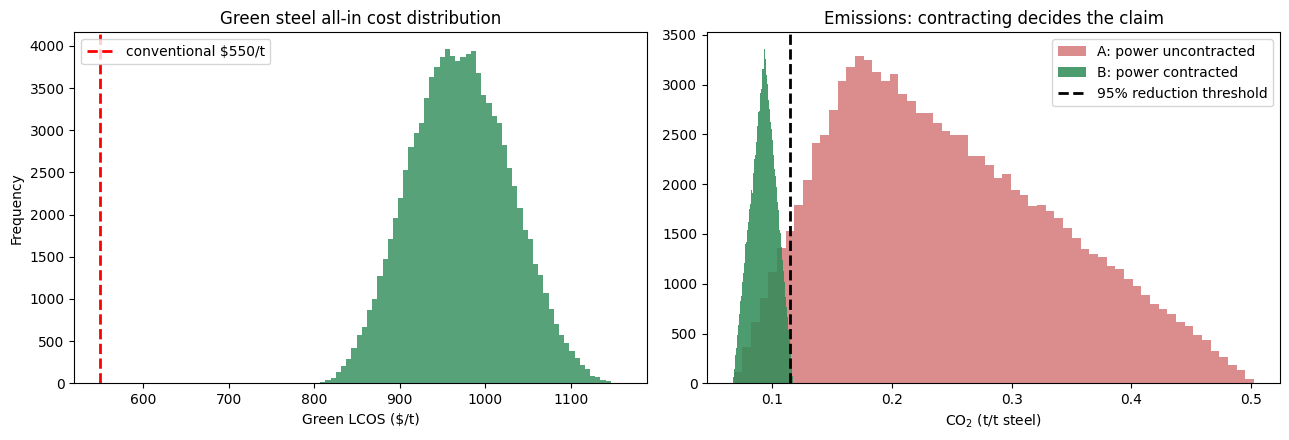

In [36]:
N = 100_000
rng = np.random.default_rng(42)

h2p   = rng.triangular(2.0, 4.0, 6.5, N)      # $/kg
elecp = rng.triangular(30, 45, 70, N)         # $/MWh
carb  = rng.triangular(0, 60, 200, N)         # $/t CO2
gridA = rng.triangular(0.02, 0.05, 0.15, N)   # power NOT contracted
gridB = rng.triangular(0.020, 0.028, 0.035,N) # power contracted

g_lcos = h2p*H2_per_t + elec_tot_kwh/1000*elecp + iron_ore_cost + other_var_cost + capex_per_t
d_lcos = conv_lcos + carb*co2_bfbof
co2_A, co2_B = elec_tot_kwh/1000*gridA, elec_tot_kwh/1000*gridB
CLAIM = 0.115   # t CO2/t needed to support a "95% reduction" claim

print(f"P(cost-competitive, full LCOS)        : {100*np.mean(g_lcos<=d_lcos):.0f}%")
print(f"P(95% CO2 claim) A — power UNcontracted: {100*np.mean(co2_A<=CLAIM):.0f}%")
print(f"P(95% CO2 claim) B — power contracted  : {100*np.mean(co2_B<=CLAIM):.0f}%")
print(f"\nMedian green LCOS: ${np.median(g_lcos):.0f}/t")
print("\n>>> The 95% claim is a PROCUREMENT outcome, not a process outcome.")
print("    Say it that way — it is both more accurate and much harder to attack.")

fig, (a1,a2) = plt.subplots(1,2, figsize=(13,4.5))
a1.hist(g_lcos, bins=60, color='seagreen', alpha=.8)
a1.axvline(conv_lcos, color='r', ls='--', lw=2, label=f'conventional ${conv_lcos:.0f}/t')
a1.set_xlabel('Green LCOS ($/t)'); a1.set_ylabel('Frequency')
a1.set_title('Green steel all-in cost distribution'); a1.legend()

a2.hist(co2_A, bins=60, alpha=.7, label='A: power uncontracted', color='indianred')
a2.hist(co2_B, bins=60, alpha=.85, label='B: power contracted', color='seagreen')
a2.axvline(CLAIM, color='k', ls='--', lw=2, label='95% reduction threshold')
a2.set_xlabel('CO$_2$ (t/t steel)'); a2.set_title('Emissions: contracting decides the claim')
a2.legend()
plt.tight_layout(); plt.show()

## 7. Market sizing

In [37]:
steel_per_MW = 120        # t/MW onshore tower
new_wind_GW  = 969        # GWEC forecast 2026-2030
steel_demand = new_wind_GW*1000*steel_per_MW
co2_saved    = steel_demand*(co2_bfbof - co2_green)

print(f"Tower steel demand 2026-2030 : {steel_demand/1e6:,.1f} Mt")
print(f"CO2 saved if all green       : {co2_saved/1e6:,.0f} Mt")
print(f"Revenue at 1% market share   : ${0.01*steel_demand*sale_price/1e9:,.1f}B over the period")

Tower steel demand 2026-2030 : 116.3 Mt
CO2 saved if all green       : 256 Mt
Revenue at 1% market share   : $1.3B over the period


## 8. Self-validation against published benchmarks

Anything more than 10% off gets flagged for review. Flags are not necessarily errors — but you
should be able to explain every one of them before you present this.

In [38]:
checks = [
    ("BF-BOF CO2 (t/t)",        co2_bfbof,                    2.30, "IRENA 2024"),
    ("Green CO2 @ clean grid",  elec_tot_kwh/1000*0.03,       0.11, "LCA studies"),
    ("Green energy (GJ/t)",     energy_green,                 14.1, "IEA (broader scope)"),
    ("Pilot revenue ($M)",      revenue/1e6,                   220, "derived"),
]
print(f"{'Metric':<26}{'model':>9}{'ref':>9}{'err':>7}   source")
print("-"*68)
for name, m, ref, src in checks:
    err = 100*abs(m-ref)/ref
    print(f"{name:<26}{m:>9.2f}{ref:>9.2f}{err:>6.0f}%   {src}"
          + ("   <-- review" if err > 10 else ""))

print("\nOn the energy flag: this model counts ELECTRICITY ONLY (electrolysis + EAF).")
print("Published ~14 GJ/t figures include pelletizing and rolling. Scope difference, not error.")

Metric                        model      ref    err   source
--------------------------------------------------------------------
BF-BOF CO2 (t/t)               2.30     2.30     0%   IRENA 2024
Green CO2 @ clean grid         0.10     0.11     8%   LCA studies
Green energy (GJ/t)           12.10    14.10    14%   IEA (broader scope)   <-- review
Pilot revenue ($M)           220.00   220.00     0%   derived

On the energy flag: this model counts ELECTRICITY ONLY (electrolysis + EAF).
Published ~14 GJ/t figures include pelletizing and rolling. Scope difference, not error.


---
## What to do with this

1. Change `h2_price` to `2.0` and re-run — watch the break-even math change. That's the
   single biggest lever on whether this business exists.
2. Change `grid_ci` to `0.37` and re-run — watch the 95% claim collapse to ~46%. That's the
   single biggest lever on whether the environmental claim survives scrutiny.
3. Replace `elec_price` with a real Kansas wind PPA number when you find one.

**Known limitations, stated plainly:** no hourly power matching, no water-use accounting for
electrolysis, capital costs are order-of-magnitude, and conventional-steel baselines are
approximate. These are the right things to attack next.

=== OPERATING BASIS: this part already works ===
  carbon $  0/t CO2  ->  break-even H2 = $1.61/kg
  carbon $ 57/t CO2  ->  break-even H2 = $4.00/kg
  carbon $ 70/t CO2  ->  break-even H2 = $4.54/kg
  carbon $ 90/t CO2  ->  break-even H2 = $5.38/kg

  At today's $4.00/kg H2, carbon needed = $57/t CO2
  EU ETS is ~$70-90/t  =>  green ALREADY wins on operations by $30-$76/t

=== WHAT ACTUALLY BREAKS IT: $370/t of capital recovery ===
  At carbon $70/t, capital budget allowed = $130/t (needs a 65% cut from today)
  At carbon $80/t, capital budget allowed = $153/t (needs a 59% cut from today)
  At carbon $90/t, capital budget allowed = $176/t (needs a 52% cut from today)

=== TWO LEVERS: scale (capex ~ capacity^0.7) and cost of capital ===
  today: pilot, commercial rates   200 kt @ 7%/15yr -> capital $370/t | LCOS $ 951/t | needs $174/t CO2
  scale only                       500 kt @ 7%/15yr -> capital $271/t | LCOS $ 852/t | needs $131/t CO2
  cheap capital only               200 kt @ 4%

<>:52: SyntaxWarning: invalid escape sequence '\$'
<>:114: SyntaxWarning: invalid escape sequence '\$'
<>:52: SyntaxWarning: invalid escape sequence '\$'
<>:114: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_3029/263142390.py:52: SyntaxWarning: invalid escape sequence '\$'
  ax.set_ylabel('Carbon price required (\$/t CO$_2$)')
/tmp/ipykernel_3029/263142390.py:114: SyntaxWarning: invalid escape sequence '\$'
  ax.set_ylabel('Carbon price required (\$/t CO$_2$)')


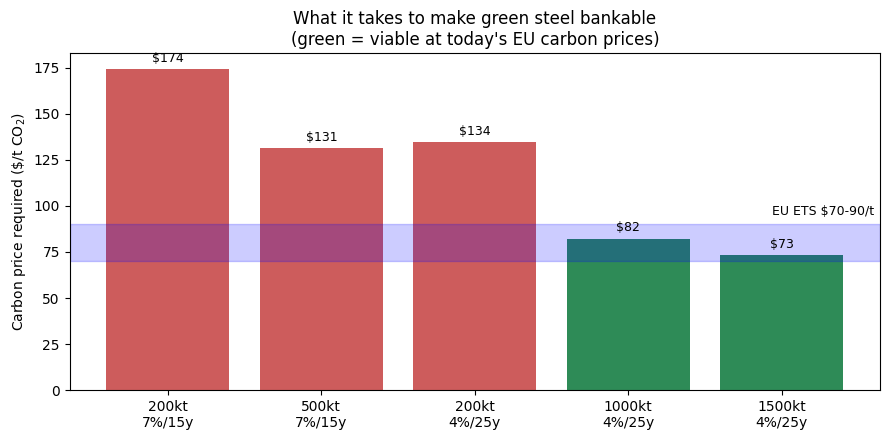


>>> CONCLUSION: this is a FINANCING and SCALE problem, not a process problem.
    A 200 kt pilot at commercial interest rates cannot work at any realistic carbon price.
    ~1 Mt/yr with concessionary capital (green bonds, DOE loan guarantee, state backing)
    lands inside today's EU carbon price range. That is the actual go-to-market question.

    Caveat: the 0.7 scaling exponent and 4%/25yr financing are assumptions, not quotes.
    Replace them with real vendor and lender numbers before relying on this.
=== OPERATING BASIS: this part already works ===
  carbon $  0/t CO2  ->  break-even H2 = $1.61/kg
  carbon $ 57/t CO2  ->  break-even H2 = $4.00/kg
  carbon $ 70/t CO2  ->  break-even H2 = $4.54/kg
  carbon $ 90/t CO2  ->  break-even H2 = $5.38/kg

  At today's $4.00/kg H2, carbon needed = $57/t CO2
  EU ETS is ~$70-90/t  =>  green ALREADY wins on operations by $30-$76/t

=== WHAT ACTUALLY BREAKS IT: $370/t of capital recovery ===
  At carbon $70/t, capital budget allowed = $130/

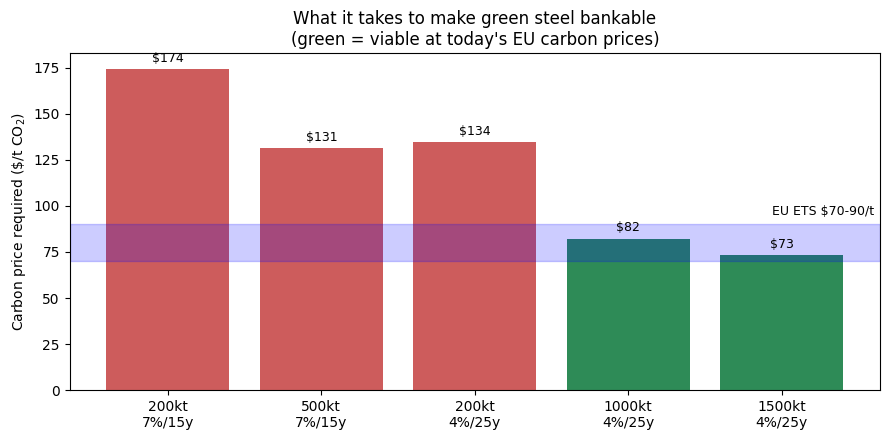


>>> CONCLUSION: this is a FINANCING and SCALE problem, not a process problem.
    A 200 kt pilot at commercial interest rates cannot work at any realistic carbon price.
    ~1 Mt/yr with concessionary capital (green bonds, DOE loan guarantee, state backing)
    lands inside today's EU carbon price range. That is the actual go-to-market question.

    Caveat: the 0.7 scaling exponent and 4%/25yr financing are assumptions, not quotes.
    Replace them with real vendor and lender numbers before relying on this.


In [39]:
# ============================================================
# 9. THE REAL CONSTRAINT: capital, not operations
# Paste as a new cell at the end of the notebook.
# ============================================================

def crf(r, n):
    """Capital recovery factor: annualizes a lump capex at rate r over n years."""
    return r*(1+r)**n / ((1+r)**n - 1)

def be_h2(carbon):
    """H2 price ($/kg) that breaks even on an OPERATING basis at a given carbon price."""
    return (conv_var + carbon*co2_bfbof - cost_elec - iron_ore_cost - other_var_cost) / H2_per_t

print("=== OPERATING BASIS: this part already works ===")
for c in [0, 57, 70, 90]:
    print(f"  carbon ${c:3.0f}/t CO2  ->  break-even H2 = ${be_h2(c):.2f}/kg")
print(f"\n  At today's ${h2_price:.2f}/kg H2, carbon needed = ${be_operating:.0f}/t CO2")
print(f"  EU ETS is ~$70-90/t  =>  green ALREADY wins on operations by "
      f"${70*co2_bfbof - be_operating*co2_bfbof:.0f}-${90*co2_bfbof - be_operating*co2_bfbof:.0f}/t")

print(f"\n=== WHAT ACTUALLY BREAKS IT: ${capex_per_t:.0f}/t of capital recovery ===")
for c in [70, 80, 90]:
    allowed = conv_lcos + c*co2_bfbof - var_cost
    print(f"  At carbon ${c}/t, capital budget allowed = ${allowed:3.0f}/t "
          f"(needs a {100*(1-allowed/capex_per_t):.0f}% cut from today)")

# --- Two levers: plant scale and cost of capital -------------
print("\n=== TWO LEVERS: scale (capex ~ capacity^0.7) and cost of capital ===")
configs = [(200,0.07,15,"today: pilot, commercial rates"),
           (500,0.07,15,"scale only"),
           (200,0.04,25,"cheap capital only"),
           (1000,0.04,25,"scale + cheap capital"),
           (1500,0.04,25,"bigger + cheap capital")]

labels, needs = [], []
for kt, r, n, label in configs:
    cx    = capex * (kt/200)**0.7          # capex scales sublinearly with size
    fx    = fixed_opex * (kt/200)**0.6     # fixed opex scales more slowly still
    per_t = (cx*crf(r, n) + fx) / (kt*1e3)
    lcos  = var_cost + per_t
    need  = (lcos - conv_lcos) / co2_bfbof
    flag  = "  <== WORKS at EU carbon prices" if need <= 90 else ""
    print(f"  {label:30s} {kt:>5} kt @ {r:.0%}/{n}yr -> capital ${per_t:3.0f}/t "
          f"| LCOS ${lcos:4.0f}/t | needs ${need:3.0f}/t CO2{flag}")
    labels.append(f"{kt}kt\n{r:.0%}/{n}y"); needs.append(need)

fig, ax = plt.subplots(figsize=(9,4.5))
bars = ax.bar(labels, needs,
              color=['indianred' if v > 90 else 'seagreen' for v in needs])
ax.axhspan(70, 90, alpha=0.20, color='blue')
ax.text(len(labels)-0.4, 95, 'EU ETS $70-90/t', fontsize=9, ha='right')
ax.set_ylabel('Carbon price required (\$/t CO$_2$)')
ax.set_title('What it takes to make green steel bankable\n(green = viable at today\'s EU carbon prices)')
for b, v in zip(bars, needs):
    ax.text(b.get_x()+b.get_width()/2, v+4, f'${v:.0f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

print("\n>>> CONCLUSION: this is a FINANCING and SCALE problem, not a process problem.")
print("    A 200 kt pilot at commercial interest rates cannot work at any realistic carbon price.")
print("    ~1 Mt/yr with concessionary capital (green bonds, DOE loan guarantee, state backing)")
print("    lands inside today's EU carbon price range. That is the actual go-to-market question.")
print("\n    Caveat: the 0.7 scaling exponent and 4%/25yr financing are assumptions, not quotes.")
print("    Replace them with real vendor and lender numbers before relying on this.")# ============================================================
# 9. THE REAL CONSTRAINT: capital, not operations
# Paste as a new cell at the end of the notebook.
# ============================================================

def crf(r, n):
    """Capital recovery factor: annualizes a lump capex at rate r over n years."""
    return r*(1+r)**n / ((1+r)**n - 1)

def be_h2(carbon):
    """H2 price ($/kg) that breaks even on an OPERATING basis at a given carbon price."""
    return (conv_var + carbon*co2_bfbof - cost_elec - iron_ore_cost - other_var_cost) / H2_per_t

print("=== OPERATING BASIS: this part already works ===")
for c in [0, 57, 70, 90]:
    print(f"  carbon ${c:3.0f}/t CO2  ->  break-even H2 = ${be_h2(c):.2f}/kg")
print(f"\n  At today's ${h2_price:.2f}/kg H2, carbon needed = ${be_operating:.0f}/t CO2")
print(f"  EU ETS is ~$70-90/t  =>  green ALREADY wins on operations by "
      f"${70*co2_bfbof - be_operating*co2_bfbof:.0f}-${90*co2_bfbof - be_operating*co2_bfbof:.0f}/t")

print(f"\n=== WHAT ACTUALLY BREAKS IT: ${capex_per_t:.0f}/t of capital recovery ===")
for c in [70, 80, 90]:
    allowed = conv_lcos + c*co2_bfbof - var_cost
    print(f"  At carbon ${c}/t, capital budget allowed = ${allowed:3.0f}/t "
          f"(needs a {100*(1-allowed/capex_per_t):.0f}% cut from today)")

# --- Two levers: plant scale and cost of capital -------------
print("\n=== TWO LEVERS: scale (capex ~ capacity^0.7) and cost of capital ===")
configs = [(200,0.07,15,"today: pilot, commercial rates"),
           (500,0.07,15,"scale only"),
           (200,0.04,25,"cheap capital only"),
           (1000,0.04,25,"scale + cheap capital"),
           (1500,0.04,25,"bigger + cheap capital")]

labels, needs = [], []
for kt, r, n, label in configs:
    cx    = capex * (kt/200)**0.7          # capex scales sublinearly with size
    fx    = fixed_opex * (kt/200)**0.6     # fixed opex scales more slowly still
    per_t = (cx*crf(r, n) + fx) / (kt*1e3)
    lcos  = var_cost + per_t
    need  = (lcos - conv_lcos) / co2_bfbof
    flag  = "  <== WORKS at EU carbon prices" if need <= 90 else ""
    print(f"  {label:30s} {kt:>5} kt @ {r:.0%}/{n}yr -> capital ${per_t:3.0f}/t "
          f"| LCOS ${lcos:4.0f}/t | needs ${need:3.0f}/t CO2{flag}")
    labels.append(f"{kt}kt\n{r:.0%}/{n}y"); needs.append(need)

fig, ax = plt.subplots(figsize=(9,4.5))
bars = ax.bar(labels, needs,
              color=['indianred' if v > 90 else 'seagreen' for v in needs])
ax.axhspan(70, 90, alpha=0.20, color='blue')
ax.text(len(labels)-0.4, 95, 'EU ETS $70-90/t', fontsize=9, ha='right')
ax.set_ylabel('Carbon price required (\$/t CO$_2$)')
ax.set_title('What it takes to make green steel bankable\n(green = viable at today\'s EU carbon prices)')
for b, v in zip(bars, needs):
    ax.text(b.get_x()+b.get_width()/2, v+4, f'${v:.0f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

print("\n>>> CONCLUSION: this is a FINANCING and SCALE problem, not a process problem.")
print("    A 200 kt pilot at commercial interest rates cannot work at any realistic carbon price.")
print("    ~1 Mt/yr with concessionary capital (green bonds, DOE loan guarantee, state backing)")
print("    lands inside today's EU carbon price range. That is the actual go-to-market question.")
print("\n    Caveat: the 0.7 scaling exponent and 4%/25yr financing are assumptions, not quotes.")
print("    Replace them with real vendor and lender numbers before relying on this.")